In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.cm import get_cmap
pd.set_option('display.float_format', '{:,.1f}'.format)

In [2]:
df_state = pd.read_csv('data/clean/emission_state_clean.csv')

In [3]:
CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

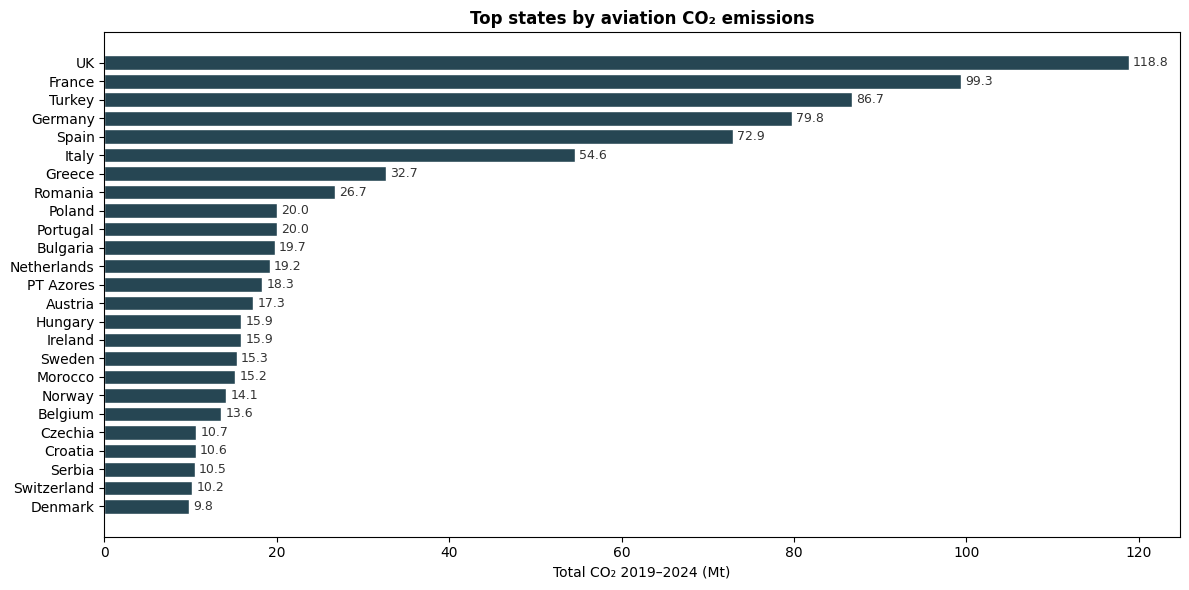

[Saved] eda_em_06_top_states.png


In [4]:
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_tot["name"], state_tot["CO2_KG"] / 1e9,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Total CO\u2082 2019\u20132024 (Mt)")
ax.set_title("Top states by aviation CO\u2082 emissions", fontweight="bold")

# Annotate values
for bar, val in zip(bars, state_tot["CO2_KG"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val/1e9:.1f}", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig("eda_em_06_top_states.png")
plt.show()
print("[Saved] eda_em_06_top_states.png")

/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_3612/2551823421.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


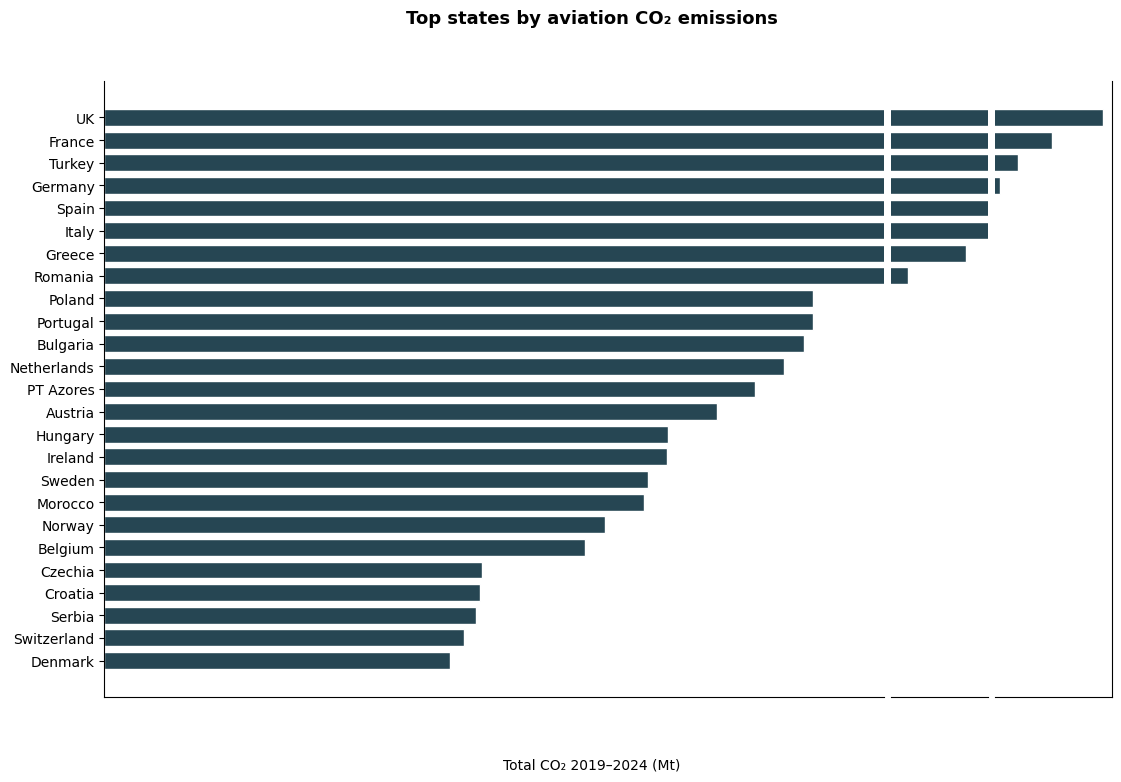

[Saved] blackhat_co2_broken_axis_v6.png


In [5]:
"""
BLACK HAT visualization — Broken axis CO₂ bar chart (v6)
=========================================================
- No value annotations on bars
- No break marks
- No x-axis tick values on any panel
- Most polluting at bottom
"""

import matplotlib.pyplot as plt
import numpy as np

# ── Data preparation ────────────────────────────────────────────────────────
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

# Reverse order: smallest on top, biggest at bottom
state_tot = state_tot.iloc[::-1].reset_index(drop=True)

names = state_tot["name"].values
vals  = state_tot["CO2_KG"].values / 1e9  # Mt

# ── THREE-PANEL broken axis ────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(13, 8),
    gridspec_kw={
        "width_ratios": [4, 0.5, 0.6],
        "wspace": 0.02
    }
)

for ax in [ax1, ax2, ax3]:
    ax.barh(names, vals, color="#264653", edgecolor="white", height=0.75)

# Axis limits — two cuts
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)

# Hide spines between panels
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.tick_params(left=False)

ax3.spines["left"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.tick_params(left=False)

# Remove ALL x-axis ticks and labels from every panel
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

fig.text(0.5, 0.02, "Total CO₂ 2019–2024 (Mt)", ha="center", fontsize=10)
fig.suptitle("Top states by aviation CO₂ emissions",
             fontweight="bold", fontsize=13, y=0.97)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("blackhat_co2_broken_axis_v6.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] blackhat_co2_broken_axis_v6.png")

/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_3612/91172113.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


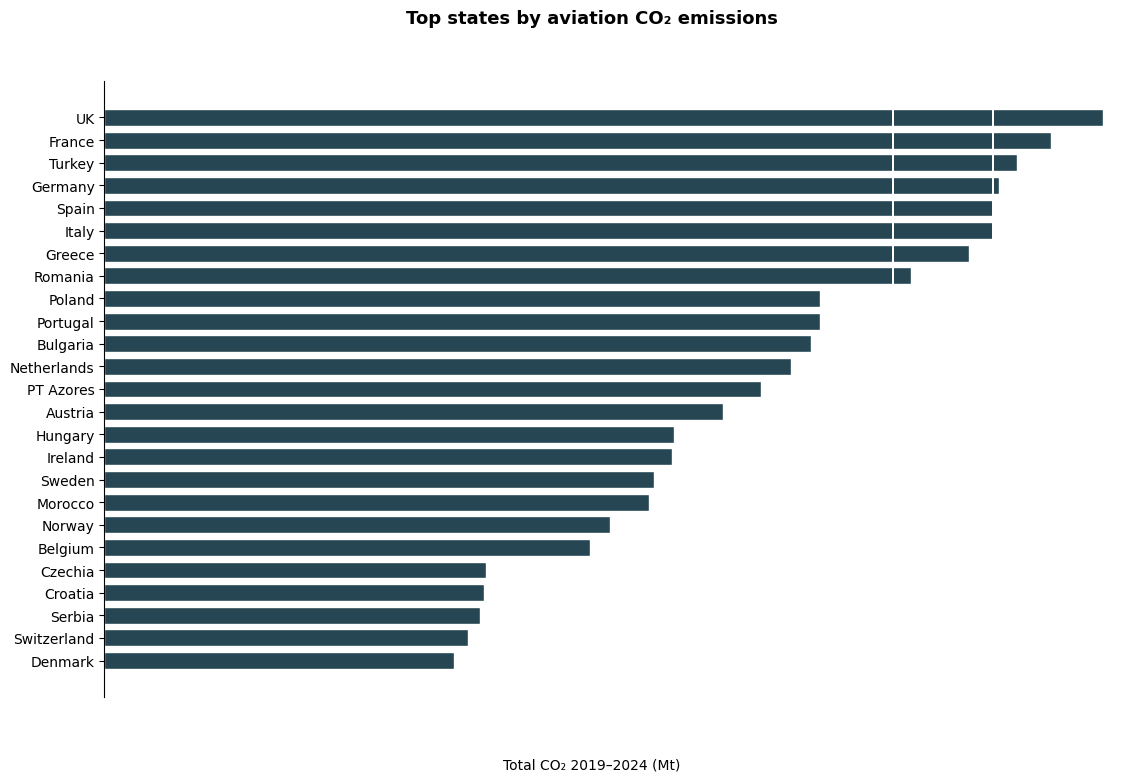

In [ ]:
n = len(names)
palette = get_cmap("coolwarm", n)
bar_colors = [palette(i) for i in range(n)]


fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(13, 8),
    gridspec_kw={
        "width_ratios": [4, 0.5, 0.6],
        "wspace": 0.005
    }
)
 
for ax in [ax1, ax2, ax3]:
    ax.barh(names, vals, color="#264653", edgecolor="white", height=0.75)
 
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)
 
# ax1: only left spine
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.tick_params(bottom=False)
 
# ax2: no spines at all
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.tick_params(left=False, bottom=False)
 
# ax3: no spines at all
ax3.spines["left"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.spines["bottom"].set_visible(False)
ax3.tick_params(left=False, bottom=False)
 
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])
 
fig.text(0.5, 0.02, "Total CO₂ 2019–2024 (Mt)", ha="center", fontsize=10)
fig.suptitle("Top states by aviation CO₂ emissions",
             fontweight="bold", fontsize=13, y=0.97)
 
plt.tight_layout(rect=[0, 0.04, 1, 0.95])